In [1]:
!pip install kagglehub

     ---------------------------------------- 0.0/40.1 kB ? eta -:--:--
     ---------- ----------------------------- 10.2/40.1 kB ? eta -:--:--
     ---------- ----------------------------- 10.2/40.1 kB ? eta -:--:--
     ------------------- ------------------- 20.5/40.1 kB 93.1 kB/s eta 0:00:01
     ------------------- ------------------- 20.5/40.1 kB 93.1 kB/s eta 0:00:01
     ----------------------------- -------- 30.7/40.1 kB 100.9 kB/s eta 0:00:01
     -------------------------------------- 40.1/40.1 kB 105.9 kB/s eta 0:00:00
   ---------------------------------------- 0.0/70.6 kB ? eta -:--:--
   ----- ---------------------------------- 10.2/70.6 kB ? eta -:--:--
   ----------------------- ---------------- 41.0/70.6 kB 487.6 kB/s eta 0:00:01
   ----------------------- ---------------- 41.0/70.6 kB 487.6 kB/s eta 0:00:01
   ----------------------- ---------------- 41.0/70.6 kB 487.6 kB/s eta 0:00:01
   ---------------------------------------- 70.6/70.6 kB 275.8 kB/s eta 0:00:00
 


[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to download:", path)

c:\Users\User\Downloads\Programs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 172k/172k [00:00<00:00, 227kB/s]

Extracting files...
Path to download: C:\Users\User\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# inspection
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nSummary statistics:")
display(df.describe())

Dataset shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# Check blank TotalCharges values
print(
    "Blank TotalCharges:",
    df["TotalCharges"].str.strip().eq("").sum()
)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check result
print("\nTotalCharges data type:", df["TotalCharges"].dtype)
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

Blank TotalCharges: 11

TotalCharges data type: float64
Missing TotalCharges: 11


In [8]:
# Churn counts
print("Churn counts:")
print(df["Churn"].value_counts())

# Churn percentages
print("\nChurn percentages:")
print(df["Churn"].value_counts(normalize=True) * 100)

# Overall churn rate
churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"\nOverall churn rate: {churn_rate:.2f}%")

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Overall churn rate: 26.54%


In [10]:
df[df["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "Contract", "Churn"]
]

df[df["TotalCharges"].isnull()][
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
].describe()

,tenure,MonthlyCharges,TotalCharges
count,11.0,11.000000,0.0
mean,0.0,41.418182,NaN
std,0.0,23.831484,NaN
min,0.0,19.700000,NaN
25%,0.0,20.125000,NaN
50%,0.0,25.750000,NaN
75%,0.0,58.975000,NaN
max,0.0,80.850000,NaN


In [11]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


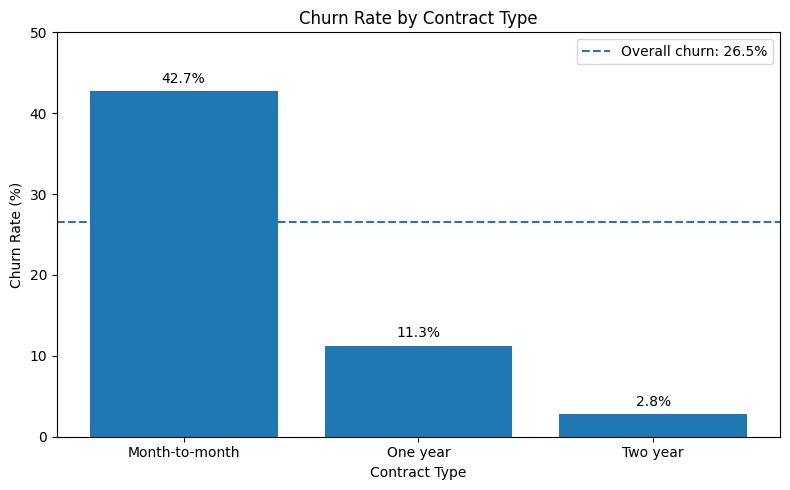

In [13]:
import matplotlib.pyplot as plt

contract_churn_rate = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

overall_churn = (df["Churn"] == "Yes").mean() * 100

plt.figure(figsize=(8, 5))

bars = plt.bar(
    contract_churn_rate.index,
    contract_churn_rate.values
)

plt.axhline(
    overall_churn,
    linestyle="--",
    label=f"Overall churn: {overall_churn:.1f}%"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for bar, value in zip(bars, contract_churn_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.legend()
plt.tight_layout()
plt.show()

In [15]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0–12 months", "13–24 months", "25–48 months", "49–72 months"]
)
tenure_churn = (
    df.groupby("TenureGroup", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(tenure_churn.round(2))

TenureGroup
0–12 months     47.44
13–24 months    28.71
25–48 months    20.39
49–72 months     9.51
Name: Churn, dtype: float64


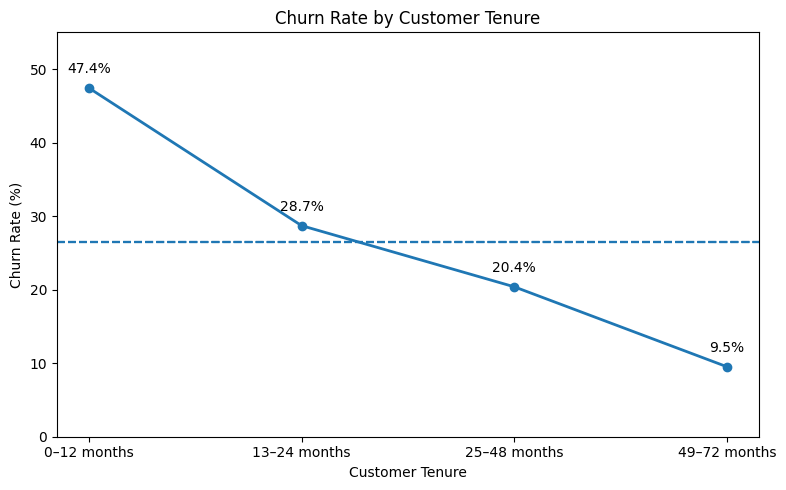

In [28]:
import matplotlib.pyplot as plt

tenure_churn = (
    df.groupby("TenureGroup", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8, 5))

plt.plot(
    tenure_churn.index,
    tenure_churn.values,
    marker="o",
    linewidth=2
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 55)


# Add percentage labels
for x, y in zip(tenure_churn.index, tenure_churn.values):
    plt.text(
        x,
        y + 2,
        f"{y:.1f}%",
        ha="center"
    )
    plt.axhline(
    26.54,
    linestyle="--",
    label=f"Overall churn: {overall_churn:.1f}%"
    )

plt.tight_layout()
plt.show()

In [18]:
contract_tenure_churn = pd.pivot_table(
    df,
    values="Churn",
    index="TenureGroup",
    columns="Contract",
    aggfunc=lambda x: (x == "Yes").mean() * 100
)

print(contract_tenure_churn.round(2))

Contract      Month-to-month  One year  Two year
TenureGroup                                     
0–12 months            51.35     10.48      0.00
13–24 months           37.72      8.12      0.00
25–48 months           32.92     10.62      2.19
49–72 months           26.02     12.93      3.33


C:\Users\User\AppData\Local\Temp\ipykernel_11188\467586517.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  contract_tenure_churn = pd.pivot_table(


In [19]:
contract_tenure_count = pd.crosstab(
    df["TenureGroup"],
    df["Contract"]
)

print(contract_tenure_count)

Contract      Month-to-month  One year  Two year
TenureGroup                                     
0–12 months             1994       124        68
13–24 months             737       197        90
25–48 months             802       518       274
49–72 months             342       634      1263


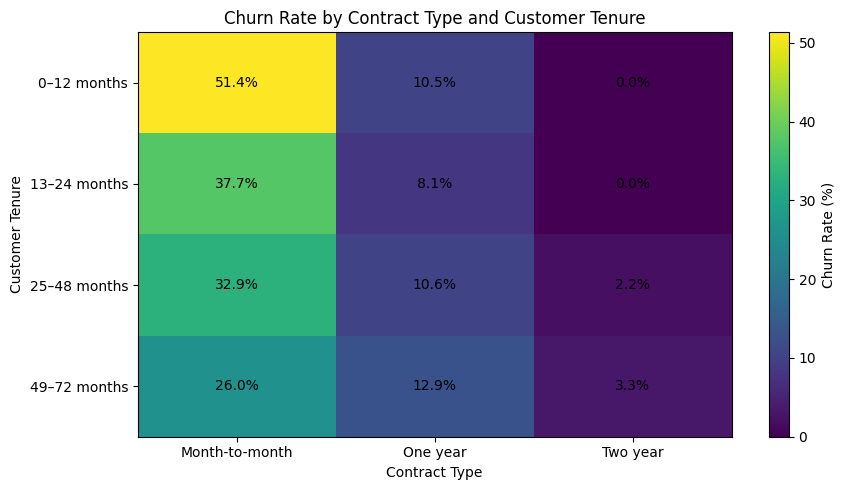

In [21]:
import matplotlib.pyplot as plt

contract_tenure_churn = pd.pivot_table(
    df,
    values="Churn",
    index="TenureGroup",
    columns="Contract",
    aggfunc=lambda x: (x == "Yes").mean() * 100,
    observed=True
)

plt.figure(figsize=(9, 5))

plt.imshow(
    contract_tenure_churn,
    aspect="auto"
)

plt.xticks(
    range(len(contract_tenure_churn.columns)),
    contract_tenure_churn.columns
)

plt.yticks(
    range(len(contract_tenure_churn.index)),
    contract_tenure_churn.index
)

plt.xlabel("Contract Type")
plt.ylabel("Customer Tenure")
plt.title("Churn Rate by Contract Type and Customer Tenure")

for i in range(len(contract_tenure_churn.index)):
    for j in range(len(contract_tenure_churn.columns)):
        value = contract_tenure_churn.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center"
        )

plt.colorbar(label="Churn Rate (%)")

plt.tight_layout()
plt.show()

In [22]:
monthly_charges_churn = (
    df.groupby("Churn")["MonthlyCharges"]
    .agg(["count", "mean", "median", "min", "max"])
)

print(monthly_charges_churn.round(2))

       count   mean  median    min     max
Churn                                     
No      5174  61.27   64.43  18.25  118.75
Yes     1869  74.44   79.65  18.85  118.35


In [24]:
df["ChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 30, 60, 90, 120],
    labels=["$0–30", "$31–60", "$61–90", "$91–120"]
)
charge_churn = (
    df.groupby("ChargeGroup", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(charge_churn.round(2))

ChargeGroup
$0–30       9.80
$31–60     25.93
$61–90     33.91
$91–120    32.78
Name: Churn, dtype: float64


In [25]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(payment_churn.round(2))

PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Churn, dtype: float64


In [26]:
payment_count = df["PaymentMethod"].value_counts()

print(payment_count)

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


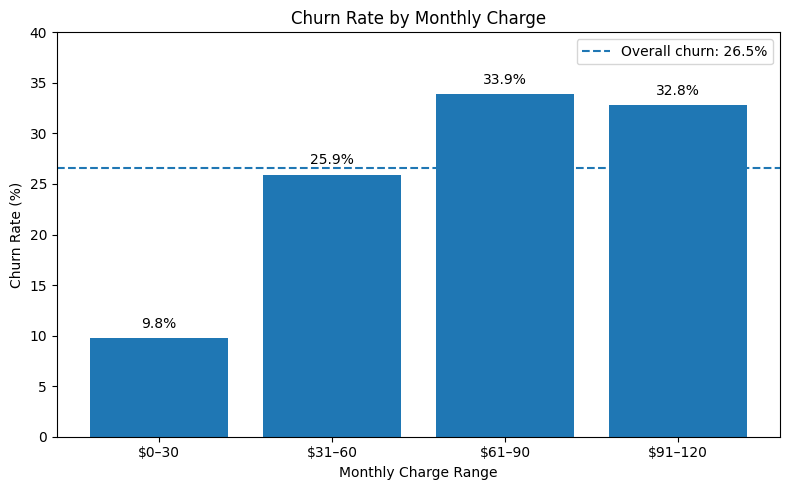

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    charge_churn.index,
    charge_churn.values
)

plt.axhline(
    overall_churn,
    linestyle="--",
    label=f"Overall churn: {overall_churn:.1f}%"
)

plt.title("Churn Rate by Monthly Charge")
plt.xlabel("Monthly Charge Range")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 40)

for bar, value in zip(bars, charge_churn.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.legend()
plt.tight_layout()
plt.show()

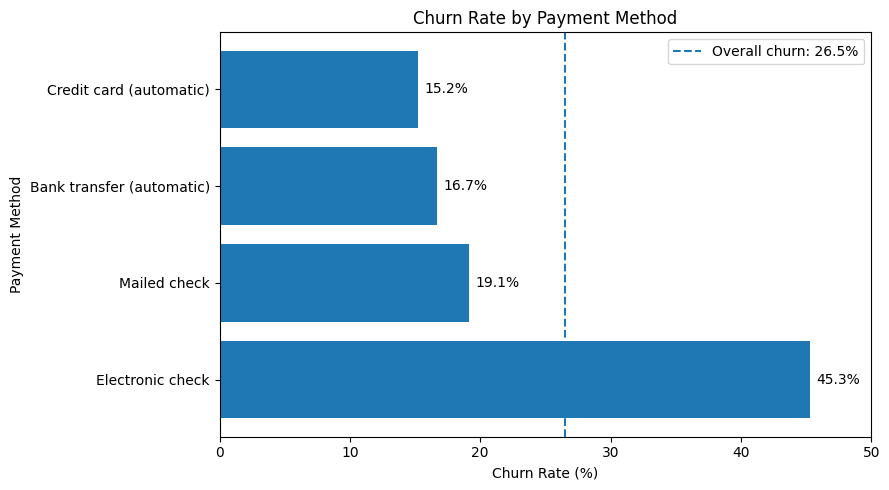

In [29]:
plt.figure(figsize=(9, 5))

bars = plt.barh(
    payment_churn.index,
    payment_churn.values
)

plt.axvline(
    overall_churn,
    linestyle="--",
    label=f"Overall churn: {overall_churn:.1f}%"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")
plt.xlim(0, 50)

for bar, value in zip(bars, payment_churn.values):
    plt.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )

plt.legend()
plt.tight_layout()
plt.show()

In [30]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(internet_churn.round(2))

InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Churn, dtype: float64


In [31]:
internet_count = df["InternetService"].value_counts()

print(internet_count)

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


In [32]:
internet_charges = (
    df.groupby("InternetService")["MonthlyCharges"]
    .agg(["count", "mean", "median"])
)

print(internet_charges.round(2))

                 count   mean  median
InternetService                      
DSL               2421  58.10   56.15
Fiber optic       3096  91.50   91.68
No                1526  21.08   20.15


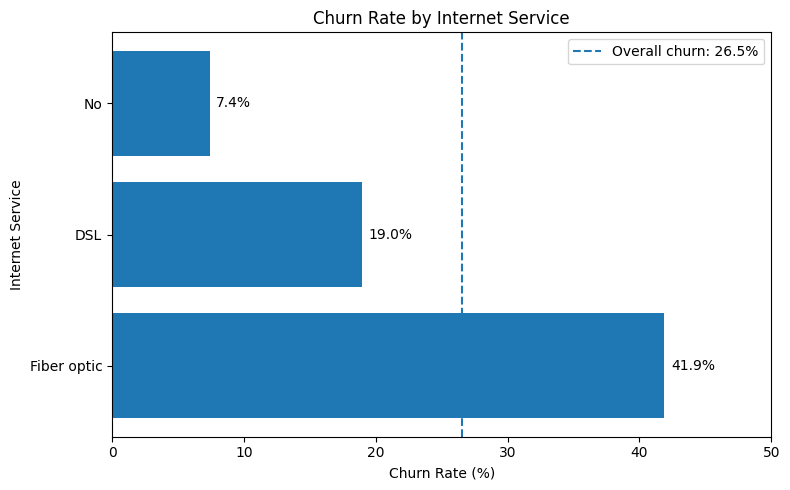

In [33]:
import matplotlib.pyplot as plt

internet_churn = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

bars = plt.barh(
    internet_churn.index,
    internet_churn.values
)

plt.axvline(
    overall_churn,
    linestyle="--",
    label=f"Overall churn: {overall_churn:.1f}%"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Internet Service")
plt.xlim(0, 50)

for bar, value in zip(bars, internet_churn.values):
    plt.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )

plt.legend()
plt.tight_layout()
plt.show()

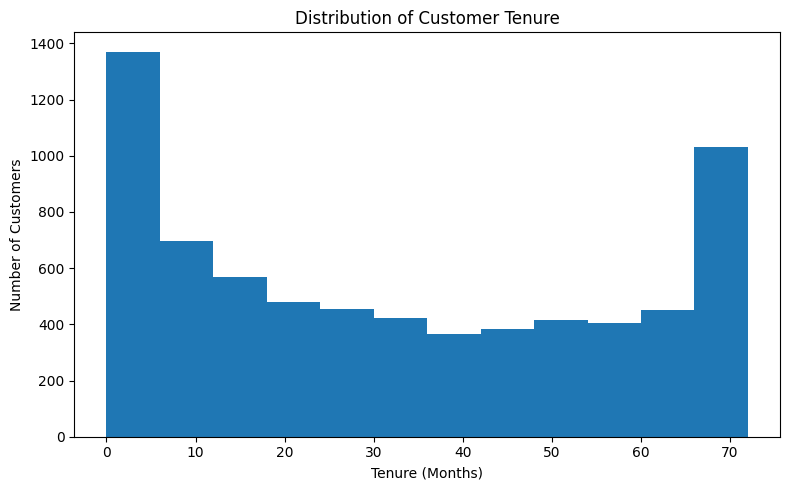

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    df["tenure"],
    bins=12
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

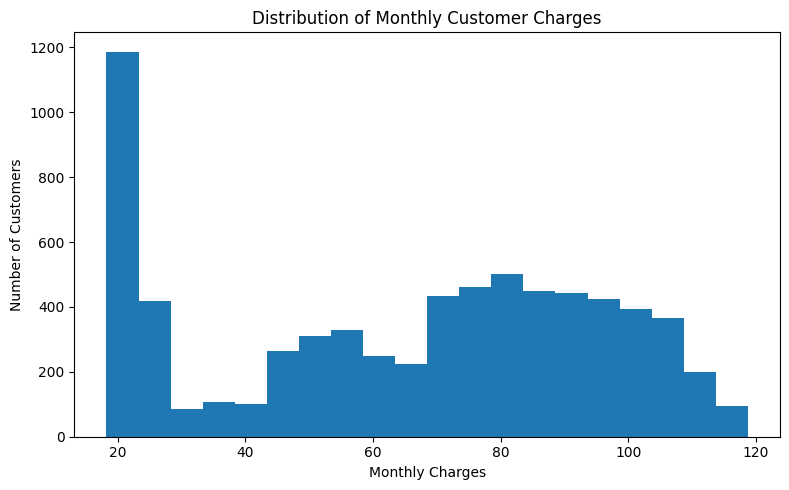

In [35]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["MonthlyCharges"],
    bins=20
)

plt.title("Distribution of Monthly Customer Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

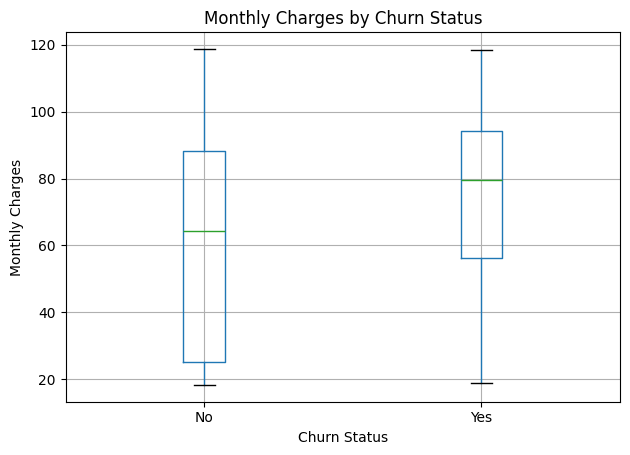

In [36]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

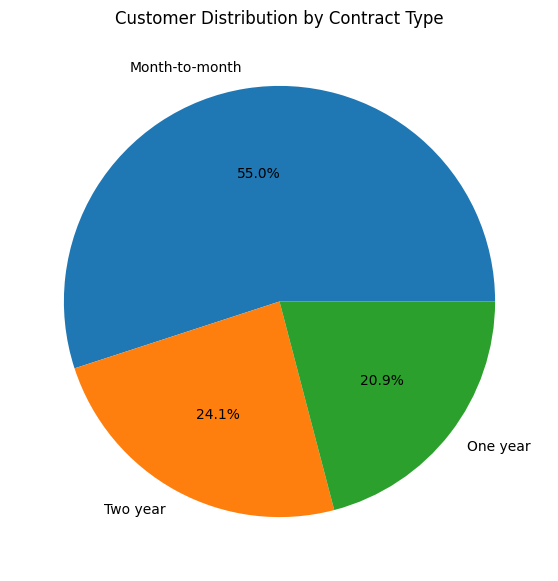

In [37]:
contract_counts = df["Contract"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    contract_counts,
    labels=contract_counts.index,
    autopct="%1.1f%%"
)

plt.title("Customer Distribution by Contract Type")

plt.show()

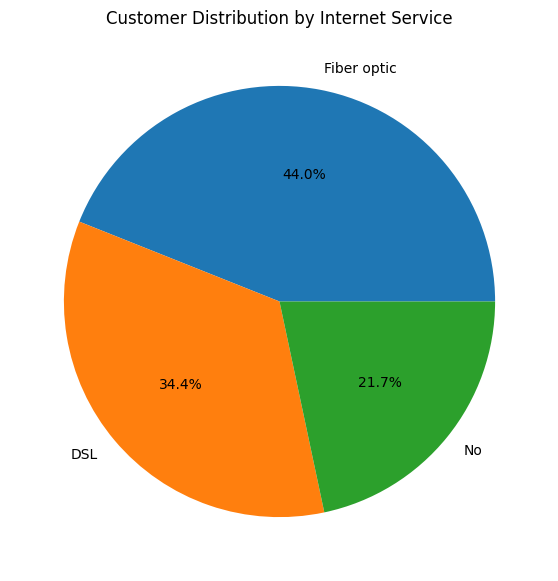

In [38]:
internet_counts = df["InternetService"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    internet_counts,
    labels=internet_counts.index,
    autopct="%1.1f%%"
)

plt.title("Customer Distribution by Internet Service")

plt.show()

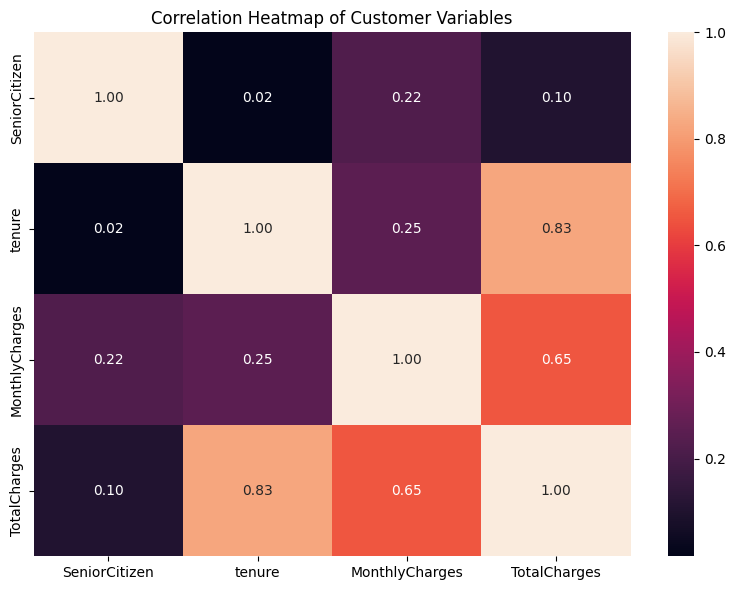

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Customer Variables")

plt.tight_layout()
plt.show()